In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import sklearn
import pandas as pd
import seaborn as sns


In [2]:
data = pd.read_csv("Car details v3.csv")

In [3]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
len(data.name.unique().tolist())

2058

In [5]:
len(data.year.unique().tolist())

29

In [6]:
df = data.copy()

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [8]:
df['name'] = le.fit_transform(df['name'])


In [9]:
df['fuel'] = le.fit_transform(df['fuel'])
df['seller_type'] = le.fit_transform(df['seller_type'])
df['transmission'] = le.fit_transform(df['transmission'])
df['owner'] = le.fit_transform(df['owner'])

In [10]:
df['year'] = le.fit_transform(df['year'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   int64  
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   int64  
 5   seller_type    8128 non-null   int64  
 6   transmission   8128 non-null   int64  
 7   owner          8128 non-null   int64  
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(8), object(4)
memory usage: 825.6+ KB


In [12]:
df['mileage']= df['mileage'].str.split(" ").str[0]

In [13]:
df.mileage = df.mileage.astype(float)

In [14]:
df['engine']= df['engine'].str.split("CC").str[0]

In [15]:

df['engine'] = df['engine'].astype(float)

In [16]:
df["max_power"] = df["max_power"].str.split(" ").str[0]


In [17]:
df['max_power']= df['max_power'].replace(['null','0','  '],df['max_power'].mode()[0])

In [18]:
df['max_power'].value_counts().sort_index()

max_power
           1
100       90
100.5      3
100.57     5
100.6     87
          ..
98.96     49
98.97      2
99        38
99.23      4
99.6       9
Name: count, Length: 321, dtype: int64

In [19]:
# Step 2: Replace empty strings or invalid entries with NaN
df['max_power'].replace(['', ' ', 'nan', 'null', 'None'], np.nan, inplace=True)

# Step 3: Convert to float
df['max_power'] = df['max_power'].astype(float)

# Step 4: (Optional) Fill missing with mean or median
df['max_power'].fillna(df['max_power'].mean(), inplace=True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_5888\2575132644.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['max_power'].replace(['', ' ', 'nan', 'null', 'None'], np.nan, inplace=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_5888\2575132644.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   int64  
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   int64  
 5   seller_type    8128 non-null   int64  
 6   transmission   8128 non-null   int64  
 7   owner          8128 non-null   int64  
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      8128 non-null   float64
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(4), int64(8), object(1)
memory usage: 825.6+ KB


In [21]:
df.drop(['torque'], axis=1, inplace=True)

In [22]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power          0
seats            221
dtype: int64

In [23]:
null_list = ['mileage', 'engine', 'seats']
for i in null_list:
    df[i].fillna(df[i].mean(), inplace= True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_5888\2820362656.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(), inplace= True)


In [24]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [25]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,1307,22,450000,145500,1,1,1,0,23.40,1248.0,74.00,5.0
1,1607,22,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0
2,385,14,158000,140000,3,1,1,4,17.70,1497.0,78.00,5.0
3,781,18,225000,127000,1,1,1,0,23.00,1396.0,90.00,5.0
4,1349,15,130000,120000,3,1,1,0,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,771,21,320000,110000,3,1,1,0,18.50,1197.0,82.85,5.0
8124,656,15,135000,119000,1,1,1,1,16.80,1493.0,110.00,5.0
8125,1319,17,382000,120000,1,1,1,0,19.30,1248.0,73.90,5.0
8126,1699,21,290000,25000,1,1,1,0,23.57,1396.0,70.00,5.0


<Axes: >

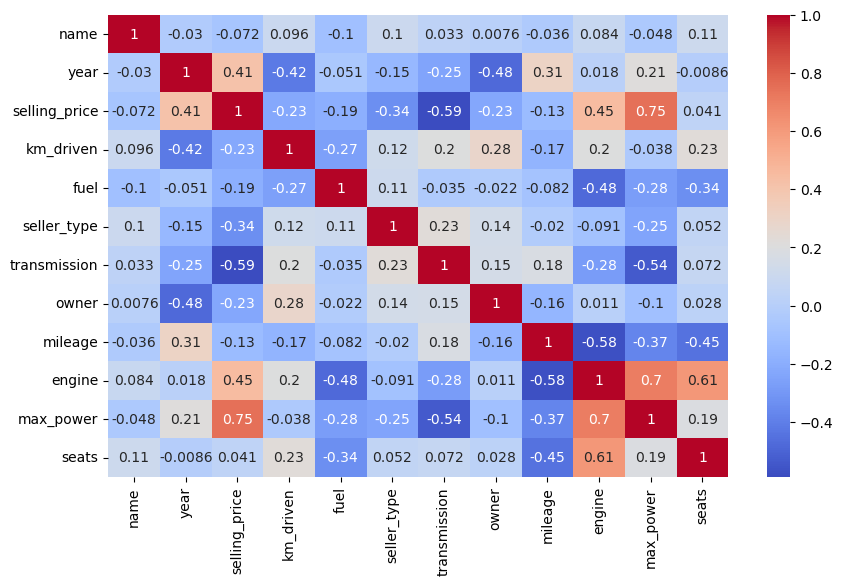

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [27]:
from sklearn.model_selection import train_test_split
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
models= {
    'RandomForest': RandomForestRegressor(),
    'LinearRegression': LinearRegression(),
    'XGBRegressor': xgboost.XGBRegressor()
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("\n")

Model: RandomForest
MAE: 65698.95024975938
MSE: 18653757376.986713
RMSE: 136578.75887921487
R2 Score: 0.9715420287238693


Model: LinearRegression
MAE: 271764.5210846844
MSE: 204079206649.95123
RMSE: 451751.2663512425
R2 Score: 0.6886589611128514


Model: XGBRegressor
MAE: 69222.8203125
MSE: 24125265920.0
RMSE: 155323.10169450004
R2 Score: 0.963194727897644




In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                               n_iter=20, cv=5, verbose=2, n_jobs=-1, scoring='r2')

rf_random.fit(X_train, y_train)

print("Best parameters:", rf_random.best_params_)
print("Best R²:", rf_random.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
   

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best R²: 0.9624802267965029


In [31]:
import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pickle
# best parameters from RandomizedSearchCV
model = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

with open("best_model.pkl", "wb") as file:
    pickle.dump(model, file)